# 📊 Patient Cohort Selection & Pattern Extraction Analysis

**Initial Population:** $\sim$65,000 patients ($\sim$80,000 ICU admissions)

---

### 1. Primary Inclusion & Exclusion Criteria
To establish the baseline study group, the following filters were applied up to the 28th day of admission:
* **Exclusion:** Severe heart disease (admitted for or coexisting).
* **Inclusion:** Invasive Mechanical Ventilation.
* **Inclusion:** Intracranial Pressure (ICP) and Central Venous Pressure (CVP) monitoring.
* **Exclusion:** Pneumonia and Intra-abdominal Pressure (IAP).
* **Exclusion:** Inconsistent Mechanical Power features (MP)
* **Resulting Population:** **7189** admissions.

---

### 2. High-Fidelity Data Filtering
Admissions were filtered for consistency across clinical parameters. Only records containing valid data for **all** the following ItemIDs were retained:

| Category | ItemIDs (Mapping) |
| :--- | :--- |
| **CVP** | `3000333` |
| **PEEP** | `3022875`, `21490855` |
| **Airway Pressure** | `4165535`, `42527086`, `42527137` |
| **Inspiratory Time** | `36304672` |
| **Respiratory Rate** | `3024171`, `3007646` |
| **Tidal Volume** | `3012410` |
| **Invasive Blood Pressure** | `21490852`, `46237481` |
| **I:E** | `3009065`

* **Final High-Fidelity Cohort:** **7189** admissions.

---

### 3. Pattern Extraction Results

* **Pattern A (Basic Hemodynamic Shift)**
    * Logic: Prior $Mean Airway Pressure/I:E$ + $CVP/PEEP$ + $\Delta PEEP$ + Future $CVP$
    * **Count:** 582298

___
# **Protective Mechanical Ventilation**

## Definition
A ventilation strategy designed to minimize ventilator-induced lung injury (VILI) while maintaining adequate gas exchange.

## Aims to Mitigate (VILI Components)
- **Volutrauma** – injury from overdistention
- **Barotrauma** – injury from excessive pressure
- **Atelectrauma** – injury from cyclical opening/closing of alveoli
- **Biotrauma** – systemic inflammatory response

## Practical Implications & Protocol Elements

### Recruitment Maneuvers
- Temporary increases in pressure to reopen collapsed alveoli

### Individualized PEEP
- Target SpO₂: 88–95%
- Optimize to prevent derecruitment while avoiding overdistention

### Tidal Volume (VT) Management
- ↓ Driving Pressure = VT / Respiratory System Compliance
- Target: <15 cm H₂O ("the less the better")
- **VT Ranges:**
  - Normal Healthy Adult: ~500 mL (roughly 7 mL/kg)
  - Mechanical Ventilation (Normal Lungs): 6–8 mL/kg PBW
  - Obstructive Disease (COPD/Asthma): 6–8 mL/kg PBW (avoiding air trapping)
  - Restrictive/ARDS: 4–8 mL/kg PBW (lung-protective strategy)

### Pressure Limits
- Plateau Pressure (Pplat): <30 cm H₂O

### Ventilation Parameters
- **I:E Ratio** – Prefer ↑ Respiratory Rate over ↑ Driving Pressure
- **FiO₂** – Maintain <0.6 when possible

### Circuit Management
- Minimal or no disconnection/suction protocols
- ↓ Frequency + ↓ Duration of interventions

### Permissive Hypercapnia
- Allow elevated PaCO₂ with pH >7.2

### Positioning
- **Prone positioning** – improves V/Q ratio (0.8–1.0)

### Adjunct Therapies
- Induced hypothermia and/or paralysis – decreases CO₂ production
- Mechanical assistant devices:
  - CO₂ removal systems
  - ECMO (Extracorporeal Membrane Oxygenation)


## Reference Indexes
- **3008047** - 	Systemic vascular Resistance index
- **21490598** - Oxygen consumption (VO2)   
- **21492228** - 	Left ventricular Cardiac output by ContinuousA
- **2000000099** -	ECMO arterial flow
- **2000000631**	 - work of breathing
- **2000000253** - vtco2
- **3044904** - Oxygen content in Blood
- **3038071** Oxygen [Partial pressure] in Mixed venous blood <br>

### Blood Pressure Indexes
- **21490653**: ICP (Intracranial Pressure)
- **3000333**: CVP (Central Venous Pressure)
- **21490852**: ABP gemiddeld (Mean Arterial Blood Pressure)
- **21490851**: Invasive Diastolic blood pressure
### Invasive Mechanical Ventilation (IMV) Concept IDs:
- **21490582**: Dynamic lung compliance
- **3004921**: Ventilation mode Ventilator (Type Beademing / Mode)
- **21490855**: PEEP measured (Eind exp. druk / PEEP gemeten)
- **3007646**: Breath rate (Ademfreq. / RR)
- **3012410**: Tidal Volume setting from Ventilator.
- **44782825**, Airway plateau pressure
- **42527120**: Expired minute Volume (Exp. minuut volume)
- **36304672**: Inspiratory Time
- **4108449**: Ventilaotr Cycletime - seconds
- **4044008**: Tracheostomy tube (Trach.stoma)
- **3024171**: Respiratory rate
- **4165535**: Airway Pressure
- **42527086**: Mean Airway Pressure
- **3009065**: 	Inspiration/Expiration setting Ventilator
- **2000000204**: FIo2 setting <br>
- **21490581**:	Lung compliance

## Protective Mechanical Ventilation
- **3024882**:  Oxygen/Total gas setting [Volume Fraction] Ventilator  <br>
- **3007469**: Breath Rate/min <br>
- **44782825**: Pleatu Pressure <br>
- **21490582**: Lung Compliance <br>

### Drugs:
- **19003953**: rocuronium <br>
- **19026674**:	pancuronium <br>


## Pneumonia
- **255848** - Pneumonia (Disorder)

## Abdominal compartment syndrome - IAP
- **4197273** - Intraabdominal pressure.

___
> # Artificial ReCode
___

In [ ]:
!pip install --quiet catboost pytorch-tabnet
print("catboost and pytorch-tabnet installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.3 MB/s eta 0:00:00
catboost and pytorch-tabnet installed.


In [ ]:
import os
from google.colab import auth
import pandas as pd
import numpy as np

Project_id = "datathon2026-483822" #@param {type:"string"}
DATASET_Project_id = 'amsterdamumcdb' #@param {type:"string"}
DATASET_ID = 'van_gogh_2026_datathon_update' #@param {type:"string"}
LOCATION = 'eu' #@param {type:"string"}

os.environ["GOOGLE_CLOUD_PROJECT"] = Project_id

try:
    auth.authenticate_user()
    print('Authenticated')
except Exception as e:
    raise RuntimeError(f"Authentication failed: {e}")

class BigQueryConfig:
    def __init__(self, Project_id: str, dataset_Project_id: str = None,
                 dataset_id: str = None, location: str = "US"):

        self.Project_id = Project_id
        self.dataset_Project_id = dataset_Project_id or Project_id
        self.dataset_id = dataset_id
        self.location = location

        self._data_table_configured = False
        self._bigquery_magics_configured = False
        self._client = None

    def setup_data_table(self, max_columns: int = 50, max_rows: int = 80000):
        try:
            get_ipython().run_line_magic('load_ext', 'google.colab.data_table')
            from google.colab.data_table import DataTable
            DataTable.max_columns = max_columns
            DataTable.max_rows = max_rows

            self._data_table_configured = True
            print(f"DataTable configured: max_columns={max_columns}, max_rows={max_rows}")

        except Exception as e:
            print(f"Failed to setup DataTable: {e}")

    def setup_bigquery_magics(self):
        try:
            if not self.dataset_id:
                raise ValueError("dataset_id is required for BigQuery magics configuration")

            get_ipython().run_line_magic('load_ext', 'bigquery_magics')
            from bigquery_magics import bigquery_magics
            from google.cloud import bigquery

            default_dataset = f"{self.dataset_Project_id}.{self.dataset_id}"
            def_config = bigquery.job.QueryJobConfig(default_dataset=default_dataset)
            bigquery_magics.context.default_query_job_config = def_config

            self._bigquery_magics_configured = True
            print(f"BigQuery magics configured with default dataset: {default_dataset}")

            return def_config

        except Exception as e:
            print(f"Failed to setup BigQuery magics: {e}")
            return None

    def create_client(self, config=None):
        try:
            from google.cloud import bigquery

            if config is None:
                config = bigquery.job.QueryJobConfig()
            self._client = bigquery.Client(
                project=self.Project_id,
                location=self.location,
                default_query_job_config=config
            )

            print(f"BigQuery client created for project: {self.Project_id} (location: {self.location})")
            return self._client

        except Exception as e:
            print(f"Failed to create BigQuery client: {e}")
            return None

    def setup_all(self, max_columns: int = 50, max_rows: int = 80000):
        print("Setting up BigQuery environment...")

        self.setup_data_table(max_columns, max_rows)
        default_config = self.setup_bigquery_magics()
        client_config = default_config or bigquery.job.QueryJobConfig()
        self.create_client(client_config)

        print("BigQuery environment setup complete!")

    @property
    def client(self):
        if self._client is None:
            from google.cloud import bigquery
            config = bigquery.job.QueryJobConfig()
            self._client = bigquery.Client(
                project=self.Project_id,
                location=self.location,
                default_query_job_config=config
            )
        return self._client

    def get_default_dataset(self):
        if not self.dataset_id:
            return None
        return f"{self.dataset_Project_id}.{self.dataset_id}"


# Re-instantiate config and client to ensure they are defined, in case the previous setup cell was not run.
# Assumes BigQueryConfig class is available globally from a prior cell.
config = BigQueryConfig(
    Project_id=Project_id,
    dataset_Project_id=DATASET_Project_id,
    dataset_id=DATASET_ID,
    location=LOCATION
)
config.setup_all()
client = config.client

# Define PatientCohortProcessor class here as well to ensure it's available
# Re-using the class definition from cell 2a998273
class PatientCohortProcessor:
    def __init__(self, client, config):
        self.client = client
        self.config = config
        self.patient_ids_df = pd.DataFrame(columns=['person_id'])
        self.time_series_df = pd.DataFrame()

        # Define concept IDs as class attributes
        self.cvp_concept_id = 3000333  # CVP (Central Venous Pressure)
        self.pneumonia_concept_id = 255848
        self.intraabdominal_concept_id = 4197273
        self.blood_pressure_concept_ids = [
            21490653, # ICP (Intracranial Pressure)
            self.cvp_concept_id,  # CVP (Central Venous Pressure)
            21490852, # ABP gemiddeld (Mean Arterial Blood Pressure)
            46237481, # Invasive Artherial Blood pressure
            21490851  # Diastolic Blood pressure
        ]
        self.imv_concept_ids = [
            3022875,  # PEEP setting Ventilator (PEEP/CPAP Set)
            21490855, # PEEP measured (Eind exp. druk / PEEP gemeten)
            3007646,  # Breath rate (Ademfreq. / RR)
            3012410,  # Tidal Volume setting from Ventilator.
            3016078,  # Peak inspiratory pressure (Piek druk)
            42527120, # Expired minute Volume (Exp. minuut volume)
            36304672, # Inspiratory Time
            3024171,  # Respiratory rate
            44782825, # Airway plateau pressure
            4165535,  # Airway Pressure
            42527086, # Mean Airway Pressure
            3024882,
            3007469,
            44782825,
            21490582
        ]
        # Consolidated list of relevant concept IDs for time-series data
        metabolical_ids = [
            3008047, 21490598, 21492228, 2000000099, 2000000631, 2000000253, 3044904, 3038071
        ]
        bp_ids = [
            21490653, 3000333, 21490852, 21490851
        ]
        imv_ids_full = [
            21490582, 3004921, 21490855, 3007646, 3012410, 44782825, 42527120, 36304672, 4108449,
            4044008, 3024171, 4165535, 42527086, 42527137, 3009065, 2000000204, 21490581, 3022875
        ]
        pmv_ids = [
            3024882, 3007469, 44782825, 21490582
        ]
        drug_ids = [
            19003953, 19026674
        ]
        spo2_ids = [
            3016502, # Oxygen saturation in Arterial blood
            40762499 # Oxygen saturation in Arterial blood by Pulse oximetry
        ]
        ph_ids = [
            3012544 # pH of Venous blood
        ]
        new_plv_measurement_ids = [
            4062985, 3032445, 1073500, 21490864, 37063053, 37045672, 37029483, 37046733, 37169170, 37170751, 42527134,
            4242700, 44791512,
            21490863, 21490580, 1001813, 37038641, 37045672, 37062064
        ]
        body_weight_ids = [
            3026600, # Body weight Estimated
            3013762, # Body weight Measured
            3025315  # Body weight
        ]

        self.patiet_features = list(set(metabolical_ids + bp_ids + imv_ids_full + pmv_ids + drug_ids + spo2_ids + ph_ids + new_plv_measurement_ids + body_weight_ids))


    def _filter_patients_by_pressure_and_exclusion(self):
        default_dataset = self.config.get_default_dataset()
        if not default_dataset:
            raise ValueError("Default dataset not configured. Ensure dataset_id is set in BigQueryConfig.")

        ID_str = ', '.join(map(str, self.blood_pressure_concept_ids))

        query = f"""
        SELECT DISTINCT m.person_id
        FROM `{default_dataset}.measurement` m
        WHERE m.measurement_concept_id IN ({ID_str})
        AND NOT EXISTS (
            SELECT 1
            FROM `{default_dataset}.condition_occurrence` co
            WHERE co.person_id = m.person_id
            AND co.condition_concept_id = {self.pneumonia_concept_id}
        )
        AND NOT EXISTS (
            SELECT 1
            FROM `{default_dataset}.measurement` m_exclude
            WHERE m_exclude.person_id = m.person_id
            AND m_exclude.measurement_concept_id = {self.intraabdominal_concept_id}
        )
        """

        query_job = self.client.query(query)
        self.patient_ids_df = query_job.to_dataframe()
        print(f"Individual Patients: {len(self.patient_ids_df)} without pneumonia or IAP")

    def _get_cardiac_concept_ids(self):
        cardiac_keywords = [
            'Cardiovasculair', 'Cardiovascular', 'CABG', 'Hart',
            'Aorta', 'reanimatie'
        ]
        if 'Cardiac' not in cardiac_keywords:
            cardiac_keywords.append('Cardiac')

        query = f"""
        SELECT
            concept_id
        FROM
            `{self.config.dataset_Project_id}.{self.config.dataset_id}.concept`
        WHERE
            (LOWER(concept_name) LIKE '%heart failure%' OR
            LOWER(concept_name) LIKE '%cardiac failure%' OR
            LOWER(concept_name) LIKE '%hf%' OR
            LOWER(concept_name) LIKE '%decompensated heart%' OR
            LOWER(concept_name) LIKE '%congestive heart failure%' OR
            LOWER(concept_name) LIKE '%cardiac%')
            AND domain_id IN ('Condition', 'Measurement', 'Observation')
        """
        cardiac_concepts_df = self.client.query(query).to_dataframe()
        cardiac_concept_ids = cardiac_concepts_df['concept_id'].tolist()

        print(f"Found {len(cardiac_concept_ids)} concept IDs related to cardiac conditions.")
        print(f"Cardiac keywords defined: {cardiac_keywords}")

        return cardiac_concept_ids, cardiac_keywords

    def _exclude_heart_related_patients(self, cardiac_concept_ids, cardiac_keywords_list):
        default_dataset = self.config.get_default_dataset()
        if not default_dataset:
            raise ValueError("Default dataset not configured. Ensure dataset_id is set in BigQueryConfig.")

        if self.patient_ids_df.empty:
            print("No patients to filter for cardiac conditions.")
            return

        cardiac_concept_ids_str = ', '.join(map(str, cardiac_concept_ids))
        cardiac_exclusion_pattern = '|'.join([re.escape(k) for k in cardiac_keywords_list])

        query = f"""
        WITH cardiac_conditions AS (
            SELECT DISTINCT person_id
            FROM `{default_dataset}.condition_occurrence`
            WHERE
                condition_concept_id IN ({cardiac_concept_ids_str})
                OR REGEXP_CONTAINS(LOWER(condition_source_value), r'(?i){cardiac_exclusion_pattern}')
        )
        SELECT person_id FROM cardiac_conditions
        """

        excluded_cardiac_patients_df = self.client.query(query).to_dataframe()
        excluded_person_ids = excluded_cardiac_patients_df['person_id'].tolist()

        initial_patient_count = len(self.patient_ids_df)
        self.patient_ids_df = self.patient_ids_df[~self.patient_ids_df['person_id'].isin(excluded_person_ids)].copy()
        remaining_patient_count = len(self.patient_ids_df)
        excluded_count = initial_patient_count - remaining_patient_count

        print(f"Initial number of patients: {initial_patient_count}")
        print(f"Number of cardiac patients excluded: {excluded_count}")
        print(f"Number of patients remaining after exclusion: {remaining_patient_count}")

    def _filter_by_mechanical_ventilation(self):
        default_dataset = self.config.get_default_dataset()
        if not default_dataset:
            raise ValueError("Default dataset not configured. Ensure dataset_id is set in BigQueryConfig.")

        str_IMVid = ','.join(map(str, self.imv_concept_ids))

        items = [f"m.measurement_concept_id IN ({str_IMVid})"]

        if not self.patient_ids_df.empty:
            filter_id = ','.join(map(str, self.patient_ids_df['person_id'].unique().tolist()))
            items.append(f"m.person_id IN ({filter_id})")
            print(f"Filtering for {len(self.patient_ids_df)} patients.")

        with_indexes = " AND ".join(items)

        query = f"""
        SELECT DISTINCT
          m.person_id
        FROM `{self.config.dataset_Project_id}.{self.config.dataset_id}.measurement` AS m
        WHERE
          {with_indexes}
        """

        print("Executing query to find patients with specified IMV measurements...")
        vent_patient_ids_df = self.client.query(query).to_dataframe()

        initial_count = len(self.patient_ids_df)
        self.patient_ids_df = self.patient_ids_df[self.patient_ids_df['person_id'].isin(vent_patient_ids_df['person_id'])].copy()

        print(f"Found {len(vent_patient_ids_df)} unique patient IDs with at least one of the specified IMV measurements.")
        print(f"\nInitial patient count before IMV filter: {initial_count}")
        print(f"Patients remaining after IMV filter: {len(self.patient_ids_df)}")

    def _add_morbidity_and_icu_data(self):
        if self.patient_ids_df.empty:
            print("Input patient_df is empty. Returning empty DataFrame and list.")
            return [], None

        query_death_records = f"""SELECT DISTINCT person_id FROM `{self.config.dataset_Project_id}.{self.config.dataset_id}.death`"""
        death_records = self.client.query(query_death_records).to_dataframe()

        self.patient_ids_df['mortality_indicator'] = 'Survived'
        self.patient_ids_df.loc[self.patient_ids_df['person_id'].isin(death_records['person_id']), 'mortality_indicator'] = 'Deceased'
        print(f"Mortality info added: {self.patient_ids_df['mortality_indicator'].value_counts().to_dict()}")

        query_inpatient_concepts = f"""
        SELECT
          concept_id
        FROM
          `{self.config.dataset_Project_id}.{self.config.dataset_id}.concept`
        WHERE
          domain_id = 'Visit' AND (
            LOWER(concept_name) LIKE '%inpatient visit%' OR
            LOWER(concept_name) LIKE '%hospitalization%' OR
            LOWER(concept_name) LIKE '%hospital visit%'
          )
        """
        inpatient_concept_df = self.client.query(query_inpatient_concepts).to_dataframe()
        icu_admission_concept_ids = inpatient_concept_df['concept_id'].tolist()
        self.patient_ids_df['icu_admissions'] = 0

        if icu_admission_concept_ids:
            icu_concept_ids_str = ','.join(map(str, icu_admission_concept_ids))
            patient_ids_str = ','.join(map(str, self.patient_ids_df['person_id'].unique().tolist()))

            query_icu_admissions = f"""
            SELECT
              vo.person_id,
              COUNT(vo.visit_occurrence_id) AS icu_admissions_count_from_query
            FROM
              `{self.config.dataset_Project_id}.{self.config.dataset_id}.visit_occurrence` AS vo
            WHERE
              vo.person_id IN ({patient_ids_str}) AND
              vo.visit_concept_id IN ({icu_concept_ids_str})
            GROUP BY
              vo.person_id
            """
            icu_admissions_count_df = self.client.query(query_icu_admissions).to_dataframe()
            print(f"Found ICU admissions for {len(icu_admissions_count_df)} patients.")

            self.patient_ids_df = pd.merge(self.patient_ids_df, icu_admissions_count_df, on='person_id', how='left')
            self.patient_ids_df['icu_admissions'] = self.patient_ids_df['icu_admissions_count_from_query'].fillna(self.patient_ids_df['icu_admissions']).astype(int)
            self.patient_ids_df.drop(columns=['icu_admissions_count_from_query'], errors='ignore', inplace=True)

        return icu_admission_concept_ids

    def _add_icu_start_dates(self, icu_admission_concept_ids):
        if self.patient_ids_df.empty:
            print("Input patient_df is empty. Returning empty DataFrame.")
            return

        default_dataset = self.config.get_default_dataset()
        if not default_dataset:
            raise ValueError("Default dataset not configured. Ensure dataset_id is set in BigQueryConfig.")
        self.patient_ids_df['earliest_icu_start_datetime'] = pd.NaT

        if not icu_admission_concept_ids:
            print("No relevant inpatient/hospitalization visit concepts provided. Cannot determine ICU start dates.")
            return

        person_ids_str = ','.join(map(str, self.patient_ids_df['person_id'].unique().tolist()))
        icu_concept_ids_str = ','.join(map(str, icu_admission_concept_ids))

        query_icu_start_dates = f"""
        SELECT
          person_id,
          MIN(visit_start_datetime) AS earliest_icu_start_datetime_from_query
        FROM
          `{default_dataset}.visit_occurrence`
        WHERE
          person_id IN ({person_ids_str}) AND
          visit_concept_id IN ({icu_concept_ids_str})
        GROUP BY
          person_id
        """

        print("Executing query to find earliest ICU admission start dates...")
        icu_start_dates_df = self.client.query(query_icu_start_dates).to_dataframe()

        if not icu_start_dates_df.empty:
            icu_start_dates_df['earliest_icu_start_datetime_from_query'] = pd.to_datetime(icu_start_dates_df['earliest_icu_start_datetime_from_query'])

            self.patient_ids_df = pd.merge(
                self.patient_ids_df,
                icu_start_dates_df[['person_id', 'earliest_icu_start_datetime_from_query']],
                on='person_id',
                how='left'
            )

            self.patient_ids_df['earliest_icu_start_datetime'] = np.where(
                self.patient_ids_df['earliest_icu_start_datetime_from_query'].notna(),
                self.patient_ids_df['earliest_icu_start_datetime_from_query'],
                self.patient_ids_df['earliest_icu_start_datetime']
            )
            self.patient_ids_df.drop(columns=['earliest_icu_start_datetime_from_query'], errors='ignore', inplace=True)
        else:
            print("No ICU start dates found in BigQuery for the given patient IDs and concept IDs. 'earliest_icu_start_datetime' remains NaT for all patients.")

        print(f"Earliest ICU admission start dates added for {len(self.patient_ids_df[self.patient_ids_df['earliest_icu_start_datetime'].notna()])} patients.")

    def _add_ventilation_durations(self):
        if self.patient_ids_df.empty:
            print("Input patient_df is empty. Returning empty DataFrame.")
            return

        default_dataset = self.config.get_default_dataset()
        if not default_dataset:
            raise ValueError("Default dataset not configured. Ensure dataset_id is set in BigQueryConfig.")

        person_ids_str = ','.join(map(str, self.patient_ids_df['person_id'].unique().tolist()))
        imv_concept_ids_str = ','.join(map(str, self.imv_concept_ids))

        if not person_ids_str or not imv_concept_ids_str:
            print("No person IDs or IMV concept IDs to query for ventilation durations.")
            self.patient_ids_df = self.patient_ids_df.assign(overall_min_vent_datetime=pd.NaT, overall_max_vent_datetime=pd.NaT, vent_duration_hours=np.nan)
            return

        query = f"""
        SELECT
            person_id,
            MIN(measurement_datetime) AS overall_min_vent_datetime,
            MAX(measurement_datetime) AS overall_max_vent_datetime
        FROM
            `{default_dataset}.measurement`
        WHERE
            person_id IN ({person_ids_str}) AND
            measurement_concept_id IN ({imv_concept_ids_str})
        GROUP BY
            person_id
        """

        print("Executing query to find overall ventilation start and end times...")
        vent_times_df = self.client.query(query).to_dataframe()

        if not vent_times_df.empty:
            vent_times_df['overall_min_vent_datetime'] = pd.to_datetime(vent_times_df['overall_min_vent_datetime'])
            vent_times_df['overall_max_vent_datetime'] = pd.to_datetime(vent_times_df['overall_max_vent_datetime'])
            vent_times_df['vent_duration_hours'] = (vent_times_df['overall_max_vent_datetime'] - vent_times_df['overall_min_vent_datetime']).dt.total_seconds() / 3600

            # Merge with the original patient_df
            self.patient_ids_df = pd.merge(self.patient_ids_df, vent_times_df, on='person_id', how='left')
            print(f"Ventilation durations added for {len(vent_times_df)} patients.")
        else:
            print("No ventilation duration data found for the given patients.")
            self.patient_ids_df = self.patient_ids_df.assign(overall_min_vent_datetime=pd.NaT, overall_max_vent_datetime=pd.NaT, vent_duration_hours=np.nan)

    def _keep_consistent_cvp_cohort(self):
        if self.patient_ids_df.empty:
            print("Input patient_df is empty. Returning empty DataFrame.")
            return

        person_ids_in_filter = ','.join(map(str, self.patient_ids_df['person_id'].unique().tolist()))
        if not person_ids_in_filter:
            print("No patient IDs in the input DataFrame to filter.")
            self.patient_ids_df = pd.DataFrame(columns=['person_id'])
            return

        default_dataset = self.config.get_default_dataset()
        if not default_dataset:
            raise ValueError("Default dataset not configured. Ensure dataset_id is set in BigQueryConfig.")

        query_cvp_patients = f"""
        SELECT DISTINCT person_id
        FROM `{default_dataset}.measurement`
        WHERE person_id IN ({person_ids_in_filter}) AND measurement_concept_id = {self.cvp_concept_id}
        """

        print("Executing query to find patients with CVP measurements...")
        cvp_patients_df = self.client.query(query_cvp_patients).to_dataframe()
        cvp_person_ids = cvp_patients_df['person_id'].tolist()

        initial_patient_count = len(self.patient_ids_df)
        self.patient_ids_df = self.patient_ids_df[self.patient_ids_df['person_id'].isin(cvp_person_ids)].copy()
        remaining_patient_count = len(self.patient_ids_df)
        included_count = remaining_patient_count

        print(f"Initial patient count: {initial_patient_count}")
        print(f"Number of patients with CVP measurements included: {included_count}")
        print(f"Number of patients remaining after filtering for CVP measurements: {remaining_patient_count}")

    def _filter_by_mechanical_power(self):
        if self.patient_ids_df.empty:
            print("Input patient_df is empty. Returning empty DataFrame.")
            return

        person_ids_str = ','.join(map(str, self.patient_ids_df['person_id'].unique().tolist()))
        if not person_ids_str:
            print("No patient IDs in the input DataFrame to filter.")
            self.patient_ids_df = pd.DataFrame(columns=['person_id'])
            return

        default_dataset = self.config.get_default_dataset()
        if not default_dataset:
            raise ValueError("Default dataset not configured. Ensure dataset_id is set in BigQueryConfig.")

        respiratory_rate_ids = [3024171, 3007646]
        tidal_volume_ids = [3012410]
        airway_pressure_ids = [4165535, 42527086, 42527137]

        where_clauses = []
        where_clauses.append(f"EXISTS (SELECT 1 FROM `{default_dataset}.measurement` m_rr WHERE m_rr.person_id = m_outer.person_id AND m_rr.measurement_concept_id IN ({','.join(map(str, respiratory_rate_ids))}))")
        where_clauses.append(f"EXISTS (SELECT 1 FROM `{default_dataset}.measurement` m_tv WHERE m_tv.person_id = m_outer.person_id AND m_tv.measurement_concept_id IN ({','.join(map(str, tidal_volume_ids))}))")
        where_clauses.append(f"EXISTS (SELECT 1 FROM `{default_dataset}.measurement` m_ap WHERE m_ap.person_id = m_outer.person_id AND m_ap.measurement_concept_id IN ({','.join(map(str, airway_pressure_ids))}))")

        combined_where_clause = ' AND '.join(where_clauses)

        query = f"""
        SELECT DISTINCT person_id
        FROM `{default_dataset}.measurement` AS m_outer
        WHERE
            m_outer.person_id IN ({person_ids_str}) AND
            {combined_where_clause}
        """

        print("Executing query to filter patients for mechanical power consistency...")
        filtered_person_ids_df = self.client.query(query).to_dataframe()

        initial_patient_count = len(self.patient_ids_df)
        self.patient_ids_df = self.patient_ids_df[self.patient_ids_df['person_id'].isin(filtered_person_ids_df['person_id'])].copy()
        remaining_patient_count = len(self.patient_ids_df)

        print(f"Initial patient count: {initial_patient_count}")
        print(f"Patients remaining after mechanical power consistency filter: {remaining_patient_count}")

    def _get_time_series_data(self, data_limit: int = None):
        if self.patient_ids_df.empty:
            print("Input patient_df is empty. Returning empty DataFrame.")
            self.time_series_df = pd.DataFrame()
            return

        default_dataset = self.config.get_default_dataset()
        if not default_dataset:
            raise ValueError("Default dataset not configured. Ensure dataset_id is set in BigQueryConfig.")

        person_ids_str = ','.join(map(str, self.patient_ids_df['person_id'].unique().tolist()))
        if not person_ids_str:
            print("No patient IDs in the input DataFrame to query.")
            self.time_series_df = pd.DataFrame()
            return

        all_concept_ids_str = ','.join(map(str, self.patiet_features))

        query = f"""
        SELECT
            m.person_id,
            m.measurement_datetime,
            m.measurement_concept_id,
            m.value_as_number,
            c.concept_name
        FROM
            `{default_dataset}.measurement` AS m
        JOIN
            `{default_dataset}.concept` AS c
        ON
            m.measurement_concept_id = c.concept_id
        WHERE
            m.person_id IN ({person_ids_str}) AND
            m.measurement_concept_id IN ({all_concept_ids_str})
        """

        if data_limit is not None:
            query += f" LIMIT {data_limit}"

        print("Executing BigQuery query to fetch time series data...")
        time_series_data_long = self.client.query(query).to_dataframe()

        if time_series_data_long.empty:
            print("No time series data found for the selected patients and concept IDs.")
            self.time_series_df = pd.DataFrame()
            return

        print(f"Fetched {len(time_series_data_long)} records.")

        time_series_data_long['measurement_datetime'] = pd.to_datetime(time_series_data_long['measurement_datetime'])

        print("Sorting DataFrame by person_id and measurement_datetime...")
        time_series_data_long = time_series_data_long.sort_values(by=['person_id', 'measurement_datetime']).reset_index(drop=True)

        print("Pivoting data to wide format...")
        self.time_series_df = time_series_data_long.pivot_table(
            index=['person_id', 'measurement_datetime'],
            columns='concept_name',
            values='value_as_number'
        ).reset_index()

        print("Applying forward-fill imputation for each patient...")

        value_columns = [col for col in self.time_series_df.columns if col not in ['person_id', 'measurement_datetime']]

        self.time_series_df[value_columns] = self.time_series_df.groupby('person_id')[value_columns].ffill()

        if 'person_id' in self.time_series_df.columns:
            cols = ['person_id'] + [col for col in self.time_series_df.columns if col != 'person_id']
            self.time_series_df = self.time_series_df[cols]
        else:
            print("Warning: 'person_id' column not found in TimeSeries_df after processing. This might indicate a data or pivoting issue.")

        print("Time series data processing complete.")

    def _search_patterns(self):
        if self.time_series_df.empty:
            print("Time series data is empty. Cannot search for patterns.")
            return pd.DataFrame()

        peep_col = next((c for c in ['Positive end expiratory pressure setting Ventilator', 'PEEP'] if c in self.time_series_df.columns), None)
        cvp_col = next((c for c in ['Central venous pressure (CVP) Mean', 'CVP'] if c in self.time_series_df.columns), None)
        ie_col = next((c for c in ['I:E Ratio', 'Inspiration/Expiration setting Ventilator'] if c in self.time_series_df.columns), None)
        map_col = next((c for c in ['Mean airway pressure', 'MAP'] if c in self.time_series_df.columns), None)

        required_cols = [peep_col, cvp_col, ie_col, map_col]
        if any(col is None for col in required_cols):
            missing_cols = [c for c, name in zip(required_cols, ['PEEP', 'CVP', 'I:E Ratio', 'Mean Airway Pressure']) if c is None]
            print(f"Missing one or more required columns for pattern search: {', '.join(missing_cols)}. Returning empty DataFrame.")
            return pd.DataFrame()

        working_df = self.time_series_df.copy()
        working_df['measurement_datetime'] = pd.to_datetime(working_df['measurement_datetime'])
        working_df = working_df.sort_values(['person_id', 'measurement_datetime'])

        cols_to_fill = [c for c in [peep_col, cvp_col, ie_col, map_col] if c is not None]

        for col in cols_to_fill:
            working_df[col] = working_df.groupby('person_id')[col].transform(
                lambda x: x.interpolate(method='linear', limit_direction='both')
            )
            working_df[col] = working_df.groupby('person_id')[col].ffill().bfill()

        working_df['prev_peep_val'] = working_df.groupby('person_id')[peep_col].shift(1)
        change_mask = ((working_df[peep_col].notna()) &
                       (working_df['prev_peep_val'].notna()) &
                       (working_df[peep_col] != working_df['prev_peep_val']))

        events = working_df[change_mask][['person_id', 'measurement_datetime', peep_col, 'prev_peep_val']].copy()
        events.rename(columns={peep_col: 'current_peep', 'prev_peep_val': 'prev_peep'}, inplace=True)

        def fetch_near(base_df, search_df, direction, tol='12h'):
            base_df['measurement_datetime'] = pd.to_datetime(base_df['measurement_datetime'])
            search_df['measurement_datetime'] = pd.to_datetime(search_df['measurement_datetime'])
            return pd.merge_asof(
                base_df.sort_values('measurement_datetime'),
                search_df.sort_values('measurement_datetime'),
                on='measurement_datetime', by='person_id',
                direction=direction, tolerance=pd.Timedelta(tol)
            )

        cvp_df = working_df.dropna(subset=[cvp_col])[['person_id', 'measurement_datetime', cvp_col]]
        results = fetch_near(events, cvp_df.rename(columns={cvp_col: 'prev_cvp'}), 'backward')
        results = fetch_near(results, cvp_df.rename(columns={cvp_col: 'next_cvp'}), 'forward')

        for feat, col_name in zip([ie_col, map_col], ['prev_ie_ratio', 'prev_map']):
            if feat:
                feat_df = working_df.dropna(subset=[feat])[['person_id', 'measurement_datetime', feat]]
                results = fetch_near(results, feat_df.rename(columns={feat: col_name}), 'backward')

        final_df = results.dropna(subset=['prev_cvp', 'next_cvp']).reset_index(drop=True)
        final_df['delta_peep'] = final_df['current_peep'] - final_df['prev_peep']

        print(f"Extraction Complete with Surround-Mean Interpolation: Found {len(final_df)} patterns.")
        return final_df

processor = PatientCohortProcessor(client, config)
processor._filter_patients_by_pressure_and_exclusion()
cardiac_ids, cardiac_keywords = processor._get_cardiac_concept_ids()
processor._exclude_heart_related_patients(cardiac_ids, cardiac_keywords)
processor._filter_by_mechanical_ventilation()
icu_admission_concept_ids = processor._add_morbidity_and_icu_data()
processor._add_icu_start_dates(icu_admission_concept_ids)
processor._add_ventilation_durations()
processor._keep_consistent_cvp_cohort()
processor._filter_by_mechanical_power()
processor._get_time_series_data(data_limit=20000000)
ml_dataset = processor._search_patterns()

print("\nHead of the final ML Dataset:")
print(ml_dataset.head())


Authenticated
Setting up BigQuery environment...
DataTable configured: max_columns=50, max_rows=80000
BigQuery magics configured with default dataset: amsterdamumcdb.van_gogh_2026_datathon_update
BigQuery client created for project: datathon2026-483822 (location: eu)
BigQuery environment setup complete!
Individual Patients: 61570 without pneumonia or IAP
Found 2769 concept IDs related to cardiac conditions.
Cardiac keywords defined: ['Cardiovasculair', 'Cardiovascular', 'CABG', 'Hart', 'Aorta', 'reanimatie', 'Cardiac']
Initial number of patients: 61570
Number of cardiac patients excluded: 18811
Number of patients remaining after exclusion: 42759
Filtering for 42759 patients.
Executing query to find patients with specified IMV measurements...
Found 36529 unique patient IDs with at least one of the specified IMV measurements.

Initial patient count before IMV filter: 42759
Patients remaining after IMV filter: 36529
Mortality info added: {'Survived': 28825, 'Deceased': 7704}
Found ICU adm

# 🔹 Stacked Ensemble Model for CVP Prediction

This ensemble model is a **super-ensemble** composed of multiple base learners whose predictions are combined via a meta-model.

---

## **Base Models**

| Model | Description | Key Notes |
|-------|------------|-----------|
| **XGBoost (XGB)** | Gradient Boosting Trees | Robust pseudo-Huber loss, early stopping, handles outliers well |
| **LightGBM (LGB)** | Histogram-based Gradient Boosting Trees | Fast, efficient, good generalization |
| **CatBoost** | Gradient Boosting Trees with Ordered Boosting | Stable with noisy targets, handles categorical features |
| **Random Forest (RF)** | Bagging-based Ensemble of Decision Trees | Reduces variance, complements boosted models |

---

## **Stacking / Meta-Model**

- **Out-of-Fold Predictions**: Predictions from each base model on training folds are collected as features.
- **Test Predictions**: Base model predictions are averaged across folds.
- **Meta-Model**: Ridge Regression is trained on the OOF predictions to optimally combine the base model outputs.




Preparing data for ML models...
Dropped 10255 rows where 'next_cvp' was zero.
Dropped 0 rows containing NaN values.
Data prepared successfully.
Training set size: 466861 samples
Test set size: 116716 samples

Training Stacked Ensemble Model...
Fold 1
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[200]	valid_0's rmse: 0.134007
Fold 2
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[195]	valid_0's rmse: 0.111503
Fold 3
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[199]	valid_0's rmse: 0.102909
Fold 4
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[198]	valid_0's rmse: 0.13036
Fold 5
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[200]	valid_0's rmse: 0.118434
[0]	train-rmse:22

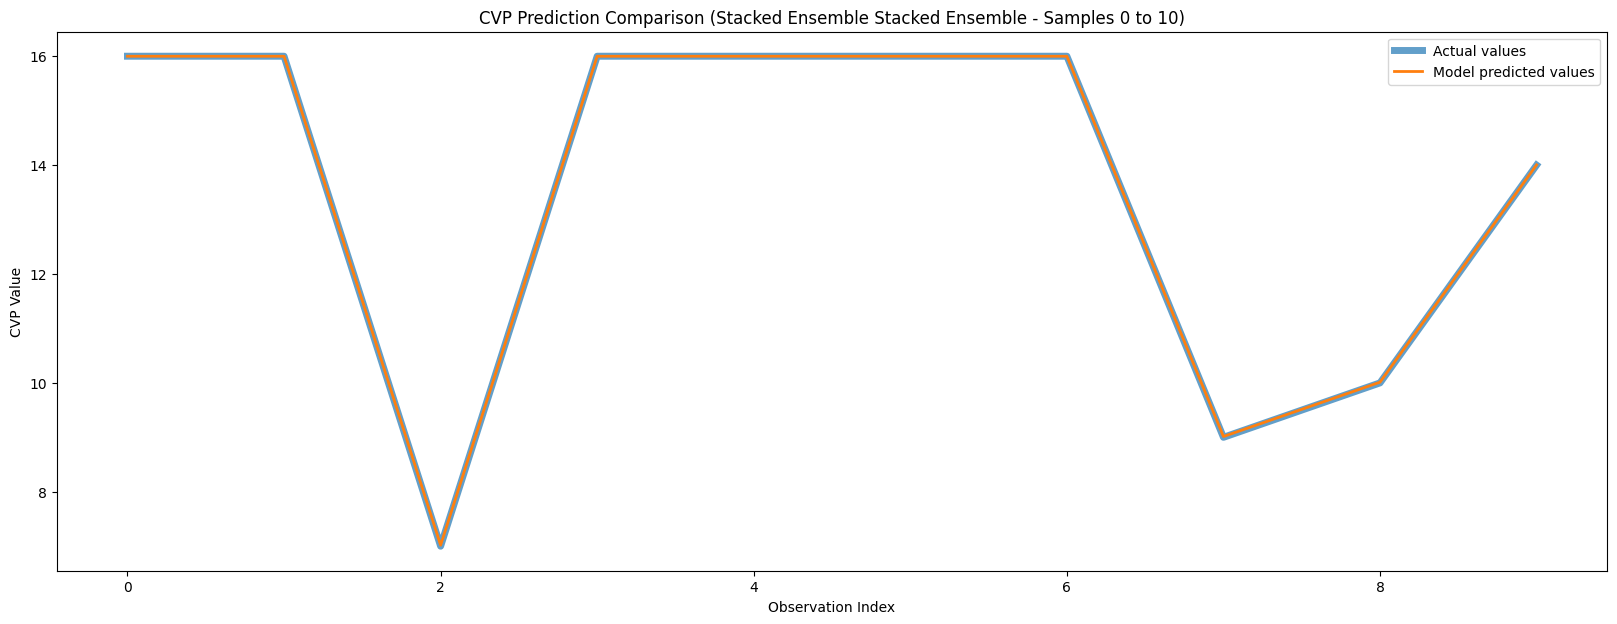

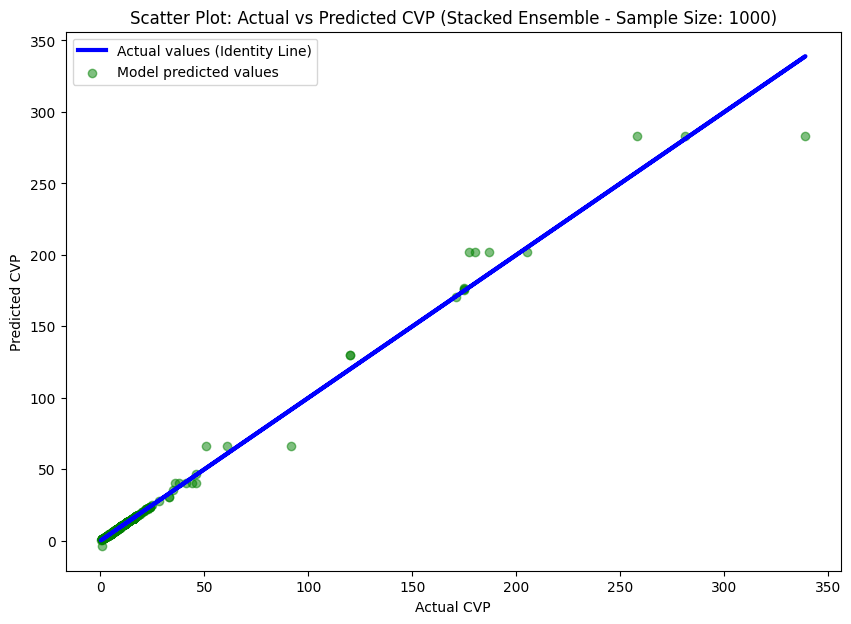


Plotting learning curves...


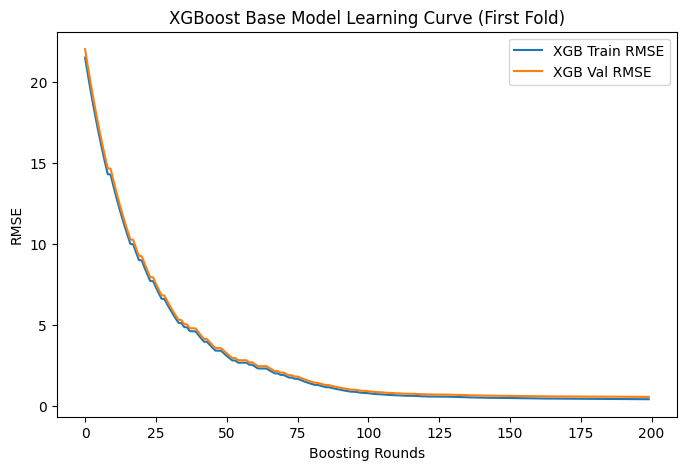

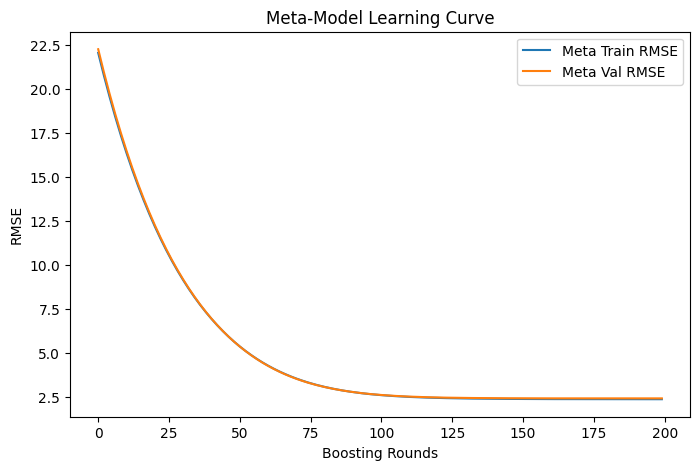


Training Standalone XGBoost Model...
[0]	train-rmse:18.21641	eval-rmse:18.39340
[200]	train-rmse:0.23486	eval-rmse:0.39005
[321]	train-rmse:0.21079	eval-rmse:0.39672

XGBOOST – CVP REGRESSION PERFORMANCE
Train RMSE: 0.2108
Test  RMSE: 0.3967
Train MAE:  0.0468
Test  MAE:  0.0644
Train R²:   0.9999
Test  R²:   0.9997

Features by Gain:
      feature         gain
     prev_cvp 52429.234375
    prev_peep     7.932126
 current_peep     5.716057
prev_ie_ratio     5.315804
   delta_peep     4.755330
     prev_map     3.948077

Visualizing Model Performance Standalone XGBoost...
Mean Absolute Error (MAE): 0.0644
Mean Squared Error (MSE): 0.1574
Root Mean Squared Error (RMSE): 0.3967
R² Score: 0.9997


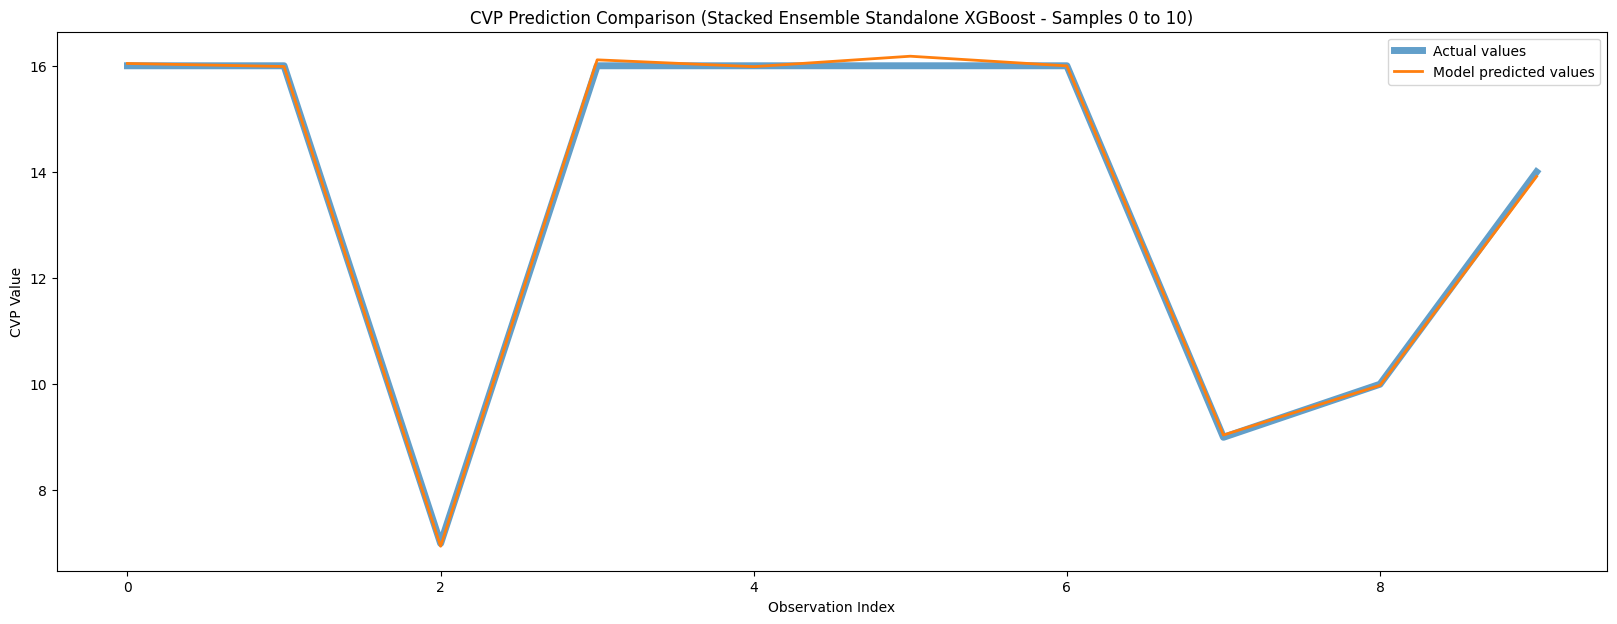

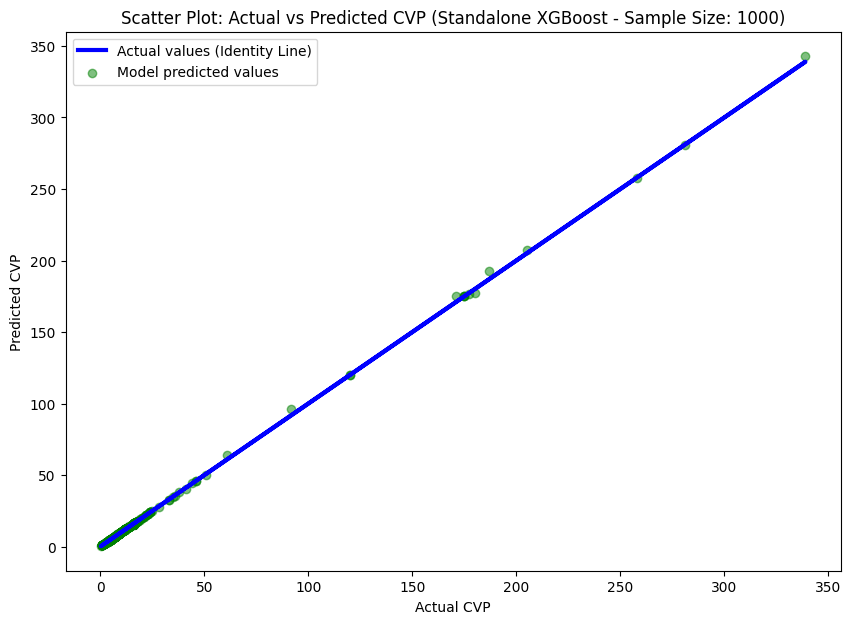

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


class CVPForecaster:
    def __init__(self, ml_dataset: pd.DataFrame):
        self.ml_dataset = ml_dataset.copy()
        self.X_train_scaled = None
        self.X_test_scaled = None
        self.y_train = None
        self.y_test = None

    def _prepare_data(self):
        print("Preparing data for ML models...")
        df_ml = self.ml_dataset.copy()

        # Drop irrelevant columns
        # Check if 'concept_name' column exists before dropping
        if 'concept_name' in df_ml.columns:
            df_ml = df_ml.drop(columns=["person_id", "measurement_datetime", "concept_name"])
        else:
            df_ml = df_ml.drop(columns=["person_id", "measurement_datetime"])


        # Filter out rows where 'next_cvp' is zero
        initial_rows = len(df_ml)
        df_ml = df_ml[df_ml['next_cvp'] != 0].copy()
        rows_after_cvp_filter = len(df_ml)
        print(f"Dropped {initial_rows - rows_after_cvp_filter} rows where 'next_cvp' was zero.")

        # Drop any remaining rows with NaN values
        initial_rows = len(df_ml)
        df_ml = df_ml.dropna().copy()
        rows_after_nan_filter = len(df_ml)
        print(f"Dropped {initial_rows - rows_after_nan_filter} rows containing NaN values.")

        if df_ml.empty:
            raise ValueError("DataFrame is empty after preprocessing. Cannot proceed with ML.")

        # Split data into features (X) and target (y)
        self.X = df_ml.drop(columns=['next_cvp'])
        self.y = df_ml['next_cvp']

        # Split into training and testing sets
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.20, random_state=42
        )

        # Scale features
        scaler = StandardScaler()
        self.X_train_scaled = pd.DataFrame(scaler.fit_transform(self.X_train), columns=self.X.columns)
        self.X_test_scaled = pd.DataFrame(scaler.transform(self.X_test), columns=self.X.columns)

        print(f"Data prepared successfully.")
        print(f"Training set size: {self.X_train_scaled.shape[0]} samples")
        print(f"Test set size: {self.X_test_scaled.shape[0]} samples")

    def _train_stacked_ensemble(self):
        print("\nTraining Stacked Ensemble Model...")
        kf = KFold(n_splits=5, shuffle=True, random_state=42)

        oof_xgb = np.zeros(len(self.X_train_scaled))
        oof_lgb = np.zeros(len(self.X_train_scaled))
        oof_cat = np.zeros(len(self.X_train_scaled))
        oof_rf = np.zeros(len(self.X_train_scaled))

        test_xgb = np.zeros(len(self.X_test_scaled))
        test_lgb = np.zeros(len(self.X_test_scaled))
        test_cat = np.zeros(len(self.X_test_scaled))
        test_rf = np.zeros(len(self.X_test_scaled))

        xgb_eval_history = []

        for fold, (tr_idx, val_idx) in enumerate(kf.split(self.X_train_scaled)):
            print(f"Fold {fold+1}")

            X_tr, X_val = self.X_train_scaled.iloc[tr_idx], self.X_train_scaled.iloc[val_idx]
            y_tr, y_val = self.y_train.iloc[tr_idx], self.y_train.iloc[val_idx]

            # XGBOOST
            dtrain = xgb.DMatrix(X_tr, label=y_tr)
            dval = xgb.DMatrix(X_val, label=y_val)

            xgb_params = {
                "objective": "reg:squarederror",
                "eval_metric": "rmse",
                "max_depth": 18,
                "min_child_weight": 20,
                "gamma": 0.1,
                "subsample": 0.8,
                "colsample_bytree": 0.8,
                "eta": 0.05,
                "reg_alpha": 0.5,
                "reg_lambda": 2.0,
                "tree_method": "hist",
                "seed": 42
            }

            fold_eval = {}

            xgb_model = xgb.train(
                xgb_params,
                dtrain,
                num_boost_round=200,
                evals=[(dtrain, "train"), (dval, "val")],
                early_stopping_rounds=300,
                evals_result=fold_eval,
                verbose_eval=False
            )

            oof_xgb[val_idx] = xgb_model.predict(dval)
            test_xgb += xgb_model.predict(xgb.DMatrix(self.X_test_scaled)) / kf.n_splits
            xgb_eval_history.append(fold_eval)

            # LIGHTGBM
            lgb_train = lgb.Dataset(X_tr, label=y_tr)
            lgb_val = lgb.Dataset(X_val, label=y_val)

            lgb_model = lgb.train(
                {
                    "objective": "regression",
                    "metric": "rmse",
                    "learning_rate": 0.05,
                    "num_leaves": 31,
                    "seed": 42,
                    "verbosity": -1
                },
                lgb_train,
                num_boost_round=200,
                valid_sets=[lgb_val],
                callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)]
            )

            oof_lgb[val_idx] = lgb_model.predict(X_val)
            test_lgb += lgb_model.predict(self.X_test_scaled) / kf.n_splits

            # CATBOOST
            cat = CatBoostRegressor(
                iterations=300,
                depth=16,
                learning_rate=0.05,
                loss_function="RMSE",
                early_stopping_rounds=200,
                random_seed=42,
                verbose=False
            )
            cat.fit(X_tr, y_tr, eval_set=(X_val, y_val))

            oof_cat[val_idx] = cat.predict(X_val)
            test_cat += cat.predict(self.X_test_scaled) / kf.n_splits

            # RANDOM FOREST
            rf = RandomForestRegressor(
                n_estimators=100,
                max_depth=18,
                min_samples_leaf=25,
                max_features="sqrt",
                n_jobs=-1,
                random_state=42
            )
            rf.fit(X_tr, y_tr)

            oof_rf[val_idx] = rf.predict(X_val)
            test_rf += rf.predict(self.X_test_scaled) / kf.n_splits

        # Stack predictions for Meta-Model
        stack_train = np.column_stack([oof_xgb, oof_lgb, oof_cat, oof_rf])
        stack_test = np.column_stack([test_xgb, test_lgb, test_cat, test_rf])

        dstack_train = xgb.DMatrix(stack_train, label=self.y_train)
        dstack_test = xgb.DMatrix(stack_test, label=self.y_test)

        meta_params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "max_depth": 40,
            "eta": 0.03,
            "subsample": 0.9,
            "colsample_bytree": 0.9,
            "reg_alpha": 0.3,
            "reg_lambda": 1.0,
            "seed": 42
        }

        meta_eval = {}

        meta_model = xgb.train(
            meta_params,
            dstack_train,
            num_boost_round=200,
            evals=[(dstack_train, "train"), (dstack_test, "val")],
            early_stopping_rounds=200,
            evals_result=meta_eval,
            verbose_eval=100
        )

        self.y_train_pred_stacked = meta_model.predict(dstack_train)
        self.y_test_pred_stacked = meta_model.predict(dstack_test)

        print("\n" + "="*60)
        print("STACKED ENSEMBLE MODEL PERFORMANCE")
        print("="*60)
        print(f"Train RMSE: {np.sqrt(mean_squared_error(self.y_train, self.y_train_pred_stacked)):.4f}")
        print(f"Test  RMSE: {np.sqrt(mean_squared_error(self.y_test, self.y_test_pred_stacked)):.4f}")
        print(f"Train MAE:  {mean_absolute_error(self.y_train, self.y_train_pred_stacked):.4f}")
        print(f"Test  MAE:  {mean_absolute_error(self.y_test, self.y_test_pred_stacked):.4f}")
        print(f"Train R²:   {r2_score(self.y_train, self.y_train_pred_stacked):.4f}")
        print(f"Test  R²:   {r2_score(self.y_test, self.y_test_pred_stacked):.4f}")

        return self.y_test_pred_stacked, meta_eval, xgb_eval_history

    def _train_xgboost_model(self):
        print("\nTraining Standalone XGBoost Model...")
        dtrain = xgb.DMatrix(self.X_train_scaled, label=self.y_train)
        dtest = xgb.DMatrix(self.X_test_scaled, label=self.y_test)

        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "max_depth": 25,
            "min_child_weight": 20,
            "gamma": 0.1,
            "reg_alpha": 0.2,
            "reg_lambda": 3.0,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "eta": 0.2,
            "seed": 42,
            "tree_method": "hist"
        }

        evals = [(dtrain, "train"), (dtest, "eval")]

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=8000,
            evals=evals,
            early_stopping_rounds=200,
            verbose_eval=200
        )

        self.y_train_pred_xgb = model.predict(dtrain)
        self.y_test_pred_xgb = model.predict(dtest)

        print("\n" + "="*60)
        print("XGBOOST – CVP REGRESSION PERFORMANCE")
        print("="*60)
        print(f"Train RMSE: {np.sqrt(mean_squared_error(self.y_train, self.y_train_pred_xgb)):.4f}")
        print(f"Test  RMSE: {np.sqrt(mean_squared_error(self.y_test, self.y_test_pred_xgb)):.4f}")
        print(f"Train MAE:  {mean_absolute_error(self.y_train, self.y_train_pred_xgb):.4f}")
        print(f"Test  MAE:  {mean_absolute_error(self.y_test, self.y_test_pred_xgb):.4f}")
        print(f"Train R²:   {r2_score(self.y_train, self.y_train_pred_xgb):.4f}")
        print(f"Test  R²:   {r2_score(self.y_test, self.y_test_pred_xgb):.4f}")

        importance = model.get_score(importance_type="gain")
        importance_df = (
            pd.DataFrame({
                "feature": list(importance.keys()),
                "gain": list(importance.values())
            })
            .sort_values("gain", ascending=False)
        )
        print("\nFeatures by Gain:")
        print(importance_df.head(20).to_string(index=False))

        return self.y_test_pred_xgb

    def _visualize_model_performance(self, y_true, y_pred, title_suffix=""):
        print(f"\nVisualizing Model Performance {title_suffix}...")
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)

        print(f"Mean Absolute Error (MAE): {mae:.4f}")
        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"R² Score: {r2:.4f}")

        def draw_result(start, end, target, y_p, plot_title):
            plt.figure(figsize=(20, 7))
            plt.plot(np.reshape(np.array(target)[start:end], -1), linewidth=5, label="Actual values", alpha=0.7)
            plt.plot(np.reshape(np.array(y_p)[start:end], -1), linewidth=2, label="Model predicted values")
            plt.title(f"CVP Prediction Comparison ({plot_title} - Samples {start} to {end})")
            plt.xlabel("Observation Index")
            plt.ylabel("CVP Value")
            plt.legend()
            plt.show()

        draw_result(0, 10, y_true, y_pred, f"Stacked Ensemble {title_suffix}")

        plt.figure(figsize=(10, 7))
        subset_size = min(1000, len(y_true))
        y_true_sub = np.reshape(np.array(y_true)[:subset_size], -1)
        y_pred_sub = np.reshape(np.array(y_pred)[:subset_size], -1)

        plt.plot(y_true_sub, y_true_sub, linewidth=3, label="Actual values (Identity Line)", color='blue')
        plt.scatter(y_true_sub, y_pred_sub, c='g', alpha=0.5, label="Model predicted values")

        plt.title(f"Scatter Plot: Actual vs Predicted CVP ({title_suffix} - Sample Size: {subset_size})")
        plt.xlabel("Actual CVP")
        plt.ylabel("Predicted CVP")
        plt.legend()
        plt.show()

forecaster = CVPForecaster(ml_dataset)
forecaster._prepare_data()

y_pred_stacked, meta_eval, xgb_eval_history = forecaster._train_stacked_ensemble()

forecaster._visualize_model_performance(forecaster.y_test, y_pred_stacked, "Stacked Ensemble")

print("\nPlotting learning curves...")
plt.figure(figsize=(8,5))
plt.plot(xgb_eval_history[0]["train"]["rmse"], label="XGB Train RMSE")
plt.plot(xgb_eval_history[0]["val"]["rmse"], label="XGB Val RMSE")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.title("XGBoost Base Model Learning Curve (First Fold)")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(meta_eval["train"]["rmse"], label="Meta Train RMSE")
plt.plot(meta_eval["val"]["rmse"], label="Meta Val RMSE")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.title("Meta-Model Learning Curve")
plt.legend()
plt.show()

y_pred_xgb = forecaster._train_xgboost_model()

forecaster._visualize_model_performance(forecaster.y_test, y_pred_xgb, "Standalone XGBoost")
